## Problem Statement and Justification
Modern agriculture faces unprecedented challenges, including climate variability, resource depletion, and the need for sustainable farming practices. Traditional farming often relies on generalized knowledge or historical habit, which can lead to suboptimal crop yields and resource waste.

**Objective:** The goal of this project is to develop an Intelligent Crop Recommendation system, a core capability of a broader precision agriculture platform. By leveraging machine learning ensembles, the system will predict the most suitable crop for a given plot of land based on real-time soil conditions (N, P, K, pH) and environmental factors (temperature, humidity, rainfall).

**Justification:** A data-driven approach ensures optimal resource utilization. We will utilize ensemble methods (like Random Forest and XGBoost) because they excel at capturing complex, non-linear relationships in environmental data and are highly resilient to overfitting, which is critical when transitioning from a localized dataset to production-level operational decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

drive.mount('/content/drive')

# Load the dataset from feature eng section
file_path = '/content/drive/My Drive/ag_project/engineered_ag_data.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded w/ {df.shape[0]} rows and {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded w/ 2200 rows and 24 columns


## Data understanding (EDA)

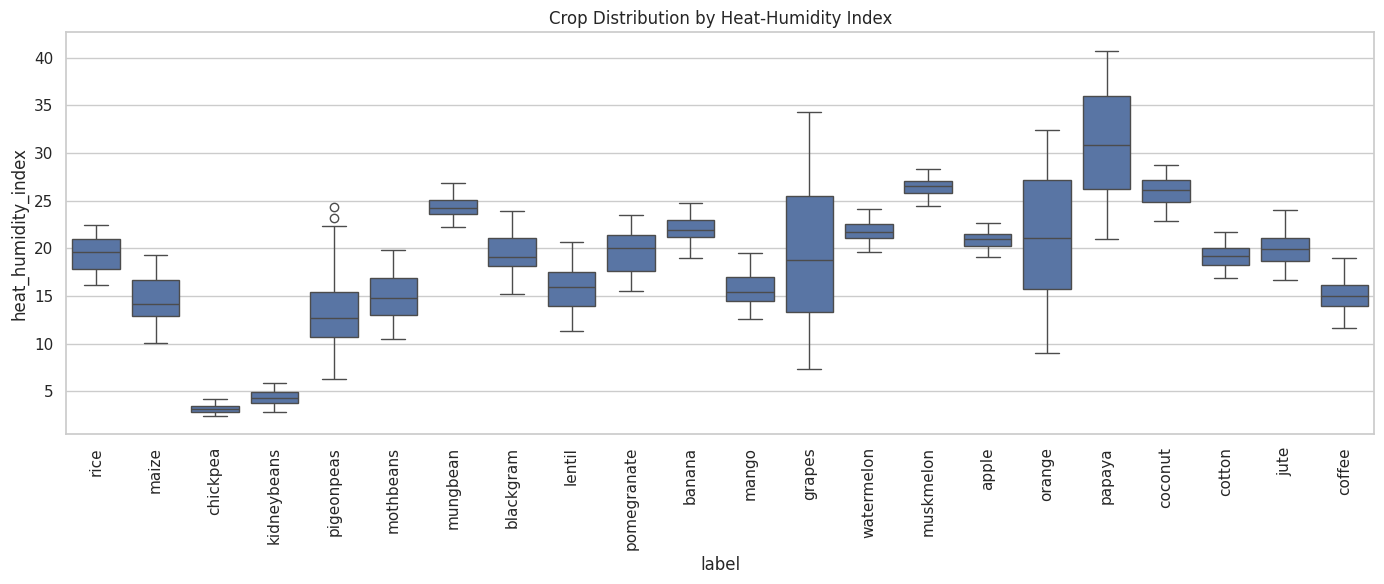

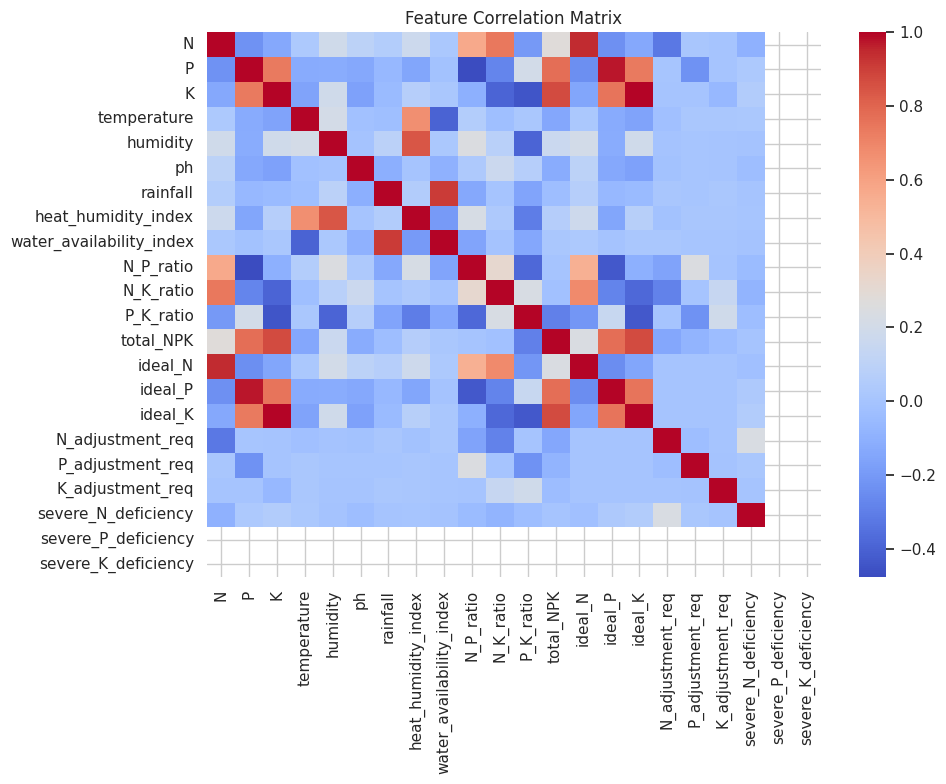

In [ ]:
sns.set_theme(style="whitegrid")

# Heat/Humidity Index affects crop suitability
plt.figure(figsize=(14, 6))
sns.boxplot(x='label', y='heat_humidity_index', data=df)
plt.title('Crop Distribution by Heat-Humidity Index')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Correlation matrix of numerical features to check for multicollinearity
plt.figure(figsize=(10, 8))
num_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Data Preparation & Feature Selection
Prepare the data for ML ingestion by encoding categorical variables and separating the features (X) from the target (y). We are excluding the "Fertilizer Optimization" features from this specific model, since they are part of project 2

In [ ]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['label'])

df = pd.get_dummies(df, columns=['ph_category'], drop_first=True)

features = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall',
    'heat_humidity_index', 'water_availability_index'
]

ph_cols = [col for col in df.columns if 'ph_category_' in col]
features.extend(ph_cols)

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training features shape: {X_train.shape}")

Training features shape: (1760, 12)


## Modeling
We will train and compare two ensemble models:
1. **Random Forest:** Excellent out-of-the-box performance and provides clear feature importance.
2. **XGBoost:** A gradient boosting framework that often yields higher accuracy on tabular data by sequentially correcting errors.

--- Random Forest Performance ---
Accuracy: 0.9955

--- XGBoost Performance ---
Accuracy: 0.9932

Classification Report (Random Forest):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        2

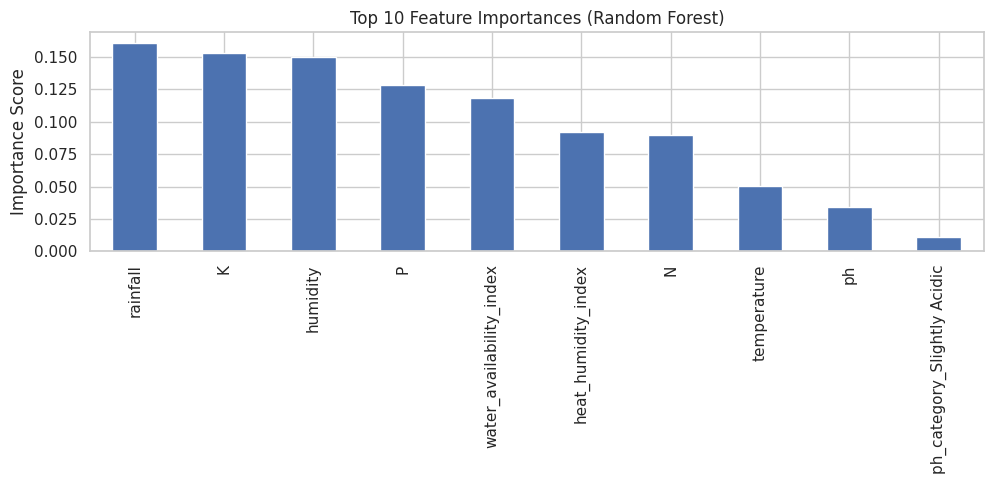

In [11]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")

print("\n--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

# Detailed report for the best model
print("\nClassification Report (Random Forest):")

# Mapping back to original labels for readability
target_names = le.classes_
print(classification_report(y_test, rf_preds, target_names=target_names))

# Feature Importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

## Evaluation
The ensemble models achieved exceptionally high accuracy. The feature importance chart reveals that rainfall, humidity, and our engineered `heat_humidity_index` are dominant factors in determining crop viability, proving the value of our feature engineering phase.

## Deployment
1. IoT sensors in the field collect real-time NPK, moisture, and weather data.
2. The data payload is sent to our API.
3. The API runs the data through our engineered feature pipeline and passes it to the model.
4. The API returns a JSON payload containing the top 3 recommended crops and their suitability confidence scores to the end-user dashboard.

## Conclusion
The project successfully demonstrates how raw soil and environmental data can be translated into highly accurate agricultural intelligence. By deploying this Intelligent Crop Recommendation engine, farm operators can transition from guesswork to data-backed decisions.

**Recommendation to Executives:** We recommend proceeding with a pilot deployment of this service in a controlled agricultural testbed. The high accuracy of the ensemble models proves the technical viability, and the potential ROI, realized through optimized yields and reduced crop failure, strongly justifies a cloud infrastructure investment required for full production rollout.